## Optimizing Diabetes Care: Balancing Intervention Costs and Readmission Reduction

### Project Overview

Hospital readmissions among diabetes patients pose a significant challenge to healthcare systems, leading to higher medical costs, increased resource strain, and poorer patient outcomes. As health systems transition from fee-for-service models to value-based care, many are implementing post-discharge intervention programs to improve care coordination and reduce preventable readmissions. However, these interventions are resource-intensive, and identifying which patients would benefit most remains a critical decision-making challenge.    

This project addresses that challenge by implementing a predict-then-optimize framework for healthcare decision-making, specifically focusing on optimizing post-discharge interventions for diabetes encounters. The approach combines machine learning prediction with optimization model to enable data-driven, cost-effective allocation of limited healthcare resources, ultimately improving patient outcomes and supporting the shift toward value-based care.

The predict-then-optimize approach consists of following two key stages:

* **Prediction Stage**: A machine learning model is used to estimate the probability of readmission for each encounter.
         
* **Optimization Stage**: These predicted probabilities are then used as inputs to an optimization model that determines which encounters should receive interventions, subject to budget constraints.

The key components in this project include:

1. **Data Preprocessing**: Clean and prepare diabetes patient data
2. **Machine Learning**: Train models to predict readmission probability
3. **Optimization**: Formulate and solve a knapsack optimization problem to determine optimal intervention allocation
4. **Evaluation**: Compare optimized allocation against naive approaches

### Import required packages

In [1]:
import pandas as pd
import numpy as np

# Data Preprocessing
from sklearn.model_selection import train_test_split, GroupShuffleSplit, cross_validate, StratifiedKFold, StratifiedGroupKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder,StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

# ML Model Training and Evaluation
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import (log_loss, brier_score_loss, roc_auc_score, average_precision_score)
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score
from sklearn.calibration import calibration_curve

# Plotting
import matplotlib.pyplot as plt

# Gurobi for optimization
import gurobipy as gp
from gurobipy import GRB


### Data Loading and Initial Exploration

#### Dataset Description

This project uses the Diabetes 130-US hospitals dataset from the UC Irvine Machine Learning Repository, which contains real-world, encounter-level data from 130 U.S. hospitals collected over a 10-year period (1999–2008). The dataset is particularly well-suited for risk prediction tasks, as it provides rich information across multiple dimensions, including:

- `Demographics` :   Age, gender, race
- `Medical History` :  Diagnoses, procedures, medications
- `Hospital Information` :  Admission type, discharge disposition, length of stay
- `Clinical Variables` :  Lab results, medication changes, diabetes medications



#### Data Loading Process

The following steps load and initially explore our dataset:

In [2]:
pd.set_option('display.max_columns', None) 
df = pd.read_csv('data/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.size

5088300

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

### Data Preprocessing: Mapping Categorical Variables

The original dataset encodes categorical variables such as admission type, discharge disposition, and admission source using numerical IDs. Since these values are not inherently interpretable, they must be mapped to their corresponding descriptive labels to improve readability and facilitate analysis.    

We utilized **`data/IDs_mapping.csv`**, which provides the following mappings:
- `Admission Type ID` → Descriptive admission type (e.g., "Emergency", "Urgent", "Elective")
- `Discharge Disposition ID` → Discharge destination (e.g., "Home", "Transfer to another facility")
- `Admission Source ID` → How patient arrived (e.g., "Physician Referral", "Emergency Room")

After applying these mappings to the dataset, we verified that no missing values were introduced during the process, ensuring data consistency and integrity.

In [5]:
# Read from data/IDs_mapping.csv to build id-value mapping.
admission_data = []
discharge_data = []
source_data = []

section = 'none'
with open('data/IDs_mapping.csv', 'r') as file:
    for line in file:
        line = line.strip()
        if not line:  
            continue
        if 'admission_type_id' in line:
            section = 'admission'
            continue
        if 'discharge_disposition_id' in line:
            section = 'discharge'
            continue
        if 'admission_source_id' in line:
            section = 'source'
            continue
            
        parts = line.split(',', 1)
        if len(parts) == 2:
            try:
                id_num = int(parts[0])
                description = parts[1].strip()
                if section == 'admission':
                    admission_data.append((id_num, description))
                elif section == 'discharge':
                    discharge_data.append((id_num, description))
                elif section == 'source':
                    source_data.append((id_num, description))
            except ValueError:
                continue

# Create mapping dictionaries
admission_type_dict = dict(admission_data)
discharge_dict = dict(discharge_data)
source_dict = dict(source_data)

# Map to the original dataset
df['admission_type_desc'] = df['admission_type_id'].map(admission_type_dict)
df['discharge_disposition_desc'] = df['discharge_disposition_id'].map(discharge_dict)
df['admission_source_desc'] = df['admission_source_id'].map(source_dict)

# Replace original ID columns with descriptive columns
columns_to_drop = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
columns_to_keep = ['admission_type_desc', 'discharge_disposition_desc', 'admission_source_desc']

# Make sure all descriptive columns are correctly mapped
print("Check missing values in mappping：")
for old_col, new_col in zip(columns_to_drop, columns_to_keep):
    null_count = df[new_col].isna().sum()
    print(f"{new_col}: {null_count} missing values")

# Drop the original id columns
df = df.drop(columns=columns_to_drop)
df.head()

Check missing values in mappping：
admission_type_desc: 0 missing values
discharge_disposition_desc: 0 missing values
admission_source_desc: 0 missing values


,encounter_id,patient_nbr,race,gender,age,weight,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type_desc,discharge_disposition_desc,admission_source_desc
0,2278392,8222157,Caucasian,Female,[0-10),?,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,NULL,Not Mapped,Physician Referral
1,149190,55629189,Caucasian,Female,[10-20),?,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,Emergency,Discharged to home,Emergency Room
2,64410,86047875,AfricanAmerican,Female,[20-30),?,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,Emergency,Discharged to home,Emergency Room
3,500364,82442376,Caucasian,Male,[30-40),?,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room
4,16680,42519267,Caucasian,Male,[40-50),?,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room


In [6]:
df.shape

(101766, 50)

In [7]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'admission_type_desc', 'discharge_disposition_desc',
       'admission_source_desc'],
      dtype='object')

### Handling Missing Values

From the **info()** summary, we confirmed that there are no missing values in the numerical columns. However, to identify potential missing or ambiguous values in the categorical columns, we examined the unique values in each column.

In [8]:
# Check how missing values are represented in categorical columns
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_features:
    print(f"=== {col} ===")
    print(df[col].unique())
    print()

=== race ===
['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']

=== gender ===
['Female' 'Male' 'Unknown/Invalid']

=== age ===
['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']

=== weight ===
['?' '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']

=== payer_code ===
['?' 'MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']

=== medical_specialty ===
['Pediatrics-Endocrinology' '?' 'InternalMedicine'
 'Family/GeneralPractice' 'Cardiology' 'Surgery-General' 'Orthopedics'
 'Gastroenterology' 'Surgery-Cardiovascular/Thoracic' 'Nephrology'
 'Orthopedics-Reconstructive' 'Psychiatry' 'Emergency/Trauma'
 'Pulmonology' 'Surgery-Neuro' 'Obsterics&Gynecology-GynecologicOnco'
 'ObstetricsandGynecology' 'Pediatrics' 'Hematology/Oncology'
 'Otolaryngology' 'Surgery-Colon&Rectal' 'Pediatrics-CriticalCare'
 'Endocrinology' 'Urology' 'Psychiatry-Child/Adol

From the above inspection, we observed that missing values were represented inconsistently across columns (e.g., "?", "Unknown", "Invalid"). Therefore, we standardized these entries by replacing them with NaN to ensure uniform representation of missing values throughout the dataset.


In [9]:
# Unify missing values
to_replace = ['?', 'Unknown/Invalid', 'PhysicianNotFound',
              'NULL', 'Not Available', 'Not Mapped']
df = df.replace(to_replace, np.nan)

Next, we calculated the percentage of missing values in each column and dropped the columns with approximately 40% missing data, as these variables provided limited information and were unlikely to contribute meaningfully to predicting readmission outcomes. For the remaining categorical features, we replaced missing values with the label “Missing” instead of imputing them with the most frequent category, as doing so could potentially distort the true distribution of the data and introduce bias into the model.

In [10]:
# Percentage of missing values for categorical columns
df.isna().mean() * 100

encounter_id                   0.000000
patient_nbr                    0.000000
race                           2.233555
gender                         0.002948
age                            0.000000
weight                        96.858479
time_in_hospital               0.000000
payer_code                    39.557416
medical_specialty             49.093017
num_lab_procedures             0.000000
num_procedures                 0.000000
num_medications                0.000000
number_outpatient              0.000000
number_emergency               0.000000
number_inpatient               0.000000
diag_1                         0.020636
diag_2                         0.351787
diag_3                         1.398306
number_diagnoses               0.000000
max_glu_serum                 94.746772
A1Cresult                     83.277322
metformin                      0.000000
repaglinide                    0.000000
nateglinide                    0.000000
chlorpropamide                 0.000000


In [11]:
# Drop columns with >35% missing values & those without distinct categories
for col in categorical_features:
    if df[col].isna().mean() > 0.35:
        df = df.drop(columns=[col]) 
    else:
        df[col] = df[col].fillna('Missing') 
df = df.drop(columns = ["examide","citoglipton"])

In [12]:
df.shape

(101766, 43)

In [13]:
# Complete handling missing value 
df.isna().mean() * 100

encounter_id                  0.0
patient_nbr                   0.0
race                          0.0
gender                        0.0
age                           0.0
time_in_hospital              0.0
num_lab_procedures            0.0
num_procedures                0.0
num_medications               0.0
number_outpatient             0.0
number_emergency              0.0
number_inpatient              0.0
diag_1                        0.0
diag_2                        0.0
diag_3                        0.0
number_diagnoses              0.0
metformin                     0.0
repaglinide                   0.0
nateglinide                   0.0
chlorpropamide                0.0
glimepiride                   0.0
acetohexamide                 0.0
glipizide                     0.0
glyburide                     0.0
tolbutamide                   0.0
pioglitazone                  0.0
rosiglitazone                 0.0
acarbose                      0.0
miglitol                      0.0
troglitazone  

### Binary Encoding for Categorical Variables

To prepare the dataset for machine learning, we converted key categorical variables into binary numeric representations for easier model interpretation and computation:
1. `change`: Whether diabetes medication was changed
   - `'No'` → 0 (no change)
   - `'Ch'` → 1 (change occurred)

2. `diabetesMed`: Whether patient is taking diabetes medication
   - `'No'` → 0 (not taking medication)
   - `'Yes'` → 1 (taking medication)

3. `readmitted`: Readmission status (our target variable)
   - `'NO'` → 0 (not readmitted)
   - `'>30'` → 1 (readmitted after 30 days)
   - `'<30'` → 1 (readmitted within 30 days)

In [14]:
df.head()

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type_desc,discharge_disposition_desc,admission_source_desc
0,2278392,8222157,Caucasian,Female,[0-10),1,41,0,1,0,0,0,250.83,Missing,Missing,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,Missing,Missing,Physician Referral
1,149190,55629189,Caucasian,Female,[10-20),3,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,Emergency,Discharged to home,Emergency Room
2,64410,86047875,AfricanAmerican,Female,[20-30),2,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,Emergency,Discharged to home,Emergency Room
3,500364,82442376,Caucasian,Male,[30-40),2,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room
4,16680,42519267,Caucasian,Male,[40-50),1,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room


In [15]:
# Check original values in columns before mapping
print("Original 'change' values:")
print(df['change'].unique())
print("\nOriginal 'diabetesMed' values:")
print(df['diabetesMed'].unique())
print("\nOriginal 'readmitted' values:")
print(df['readmitted'].unique())

Original 'change' values:
['No' 'Ch']

Original 'diabetesMed' values:
['No' 'Yes']

Original 'readmitted' values:
['NO' '>30' '<30']


In [16]:
# Mapping change to binary
change_map = {'No': 0,
              'Ch': 1
}
df['change'] = df['change'].map(change_map) 

# Mapping diabetesMed to binary
med_map = {'No': 0,
           'Yes': 1
}
df['diabetesMed'] = df['diabetesMed'].map(med_map)

# Mapping readmitted to binary
readmitted_map = {'NO': 0,
                  '>30': 1,
                  '<30': 1
}
df['readmitted'] = df['readmitted'].map(readmitted_map)

df.head()

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type_desc,discharge_disposition_desc,admission_source_desc
0,2278392,8222157,Caucasian,Female,[0-10),1,41,0,1,0,0,0,250.83,Missing,Missing,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,0,Missing,Missing,Physician Referral
1,149190,55629189,Caucasian,Female,[10-20),3,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,1,1,1,Emergency,Discharged to home,Emergency Room
2,64410,86047875,AfricanAmerican,Female,[20-30),2,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,1,0,Emergency,Discharged to home,Emergency Room
3,500364,82442376,Caucasian,Male,[30-40),2,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,1,1,0,Emergency,Discharged to home,Emergency Room
4,16680,42519267,Caucasian,Male,[40-50),1,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,1,1,0,Emergency,Discharged to home,Emergency Room


### Train/Test Split with Patient-Level Separation

Before performing feature selection and model training, we first conducted a train-test split to ensure that all subsequent preprocessing steps were applied only to the training data. Since this is encounter-level data, multiple records may correspond to the same patient.     

To prevent data leakage and overfitting, we used **GroupShuffleSplit**, grouping by `patient_nbr` so that all encounters for a given patient appear exclusively in either the training or testing set.
This approach prevents the model from learning patient-specific patterns and improves its ability to generalize to new patients during evaluation.

In addition, we performed stratified sampling based on the readmission outcome to preserve the proportion of positive and negative classes across both splits. This ensures that the model is trained and evaluated on datasets with similar class distributions, improving the reliability and fairness of performance metrics.

In [17]:
# First get original distribution
y_full = df['readmitted']
print("\nOriginal distribution:")
print(y_full.value_counts(normalize=True))

# Perform group-based split to avoid patient overlap
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df['readmitted'], groups=df['patient_nbr']))

# Split the data
X_train = df.iloc[train_idx].drop(columns=['readmitted'])
X_test = df.iloc[test_idx].drop(columns=['readmitted'])
y_train = df.iloc[train_idx]['readmitted']
y_test = df.iloc[test_idx]['readmitted']

# Save groups for use in cross-validation
groups_train = df.iloc[train_idx]['patient_nbr']

# Size of training and testing sets
print("\nDataset sizes:")
print("-" * 50)
print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

# Check label distribution across training and testing sets
print("\nLabel distribution:")
print("-" * 50)
print("\nTraining dataset:")
print(y_train.value_counts(normalize=True))
print("\nTesting dataset:")
print(y_test.value_counts(normalize=True))

# Verify no patient overlap between train and test
train_patients = set(X_train['patient_nbr'])
test_patients = set(X_test['patient_nbr'])
overlap = train_patients.intersection(test_patients)
print("\nData split validation:")
print("-" * 50)
print(f"Number of overlapping patients between train and test: {len(overlap)}")
print(f"Percentage of test patients in training: {len(overlap)/len(test_patients)*100:.2f}%")


Original distribution:
readmitted
0    0.539119
1    0.460881
Name: proportion, dtype: float64

Dataset sizes:
--------------------------------------------------
Training set: (81613, 42)
Testing set:  (20153, 42)

Label distribution:
--------------------------------------------------

Training dataset:
readmitted
0    0.537292
1    0.462708
Name: proportion, dtype: float64

Testing dataset:
readmitted
0    0.546519
1    0.453481
Name: proportion, dtype: float64

Data split validation:
--------------------------------------------------
Number of overlapping patients between train and test: 0
Percentage of test patients in training: 0.00%


### Feature Selection: Identifying Predictive Variables

To train a model capable of predicting readmission risk for each encounter, we focused on selecting the variables that are most predictive of the target outcome. 
  
We evaluated the relationship between each feature and the target variable (readmitted) separately for numerical and categorical columns





#### Numerical Feature Analysis: Point-Biserial Correlation

First, to measure the strength and direction of the relationship between each numerical feature and the binary readmission target, we applied the point-biserial correlation test. This method quantifies how strongly a continuous variable is associated with a binary outcome, allowing us to identify which numerical variables are most informative for predicting readmission risk.

Point-biserial correlation measures the strength and direction of the linear relationship between continuous variables (our numerical features) and the binary variable (our readmission target: 0/1).

To assess the significance of these relationships, we examined both the correlation coefficient (indicating the strength and direction of association) and the p-value (indicating statistical significance). Features with stronger correlations and lower p-values were considered more predictive and prioritized for model inclusion.


In [18]:
# Split numeric and categorical features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# Use point-biserial correlation for numeric features
num_corr = []
for col in numeric_features:
    corr, pval = pointbiserialr(X_train[col], y_train)
    num_corr.append({"feature": col,
                    "correlation": corr,
                    "p_value": pval})

# Check correlation results
num_corr_df = pd.DataFrame(num_corr).sort_values(by="p_value", ascending=True)
print(num_corr_df)


               feature  correlation        p_value
8     number_inpatient     0.214869   0.000000e+00
9     number_diagnoses     0.112523  3.804819e-228
7     number_emergency     0.099609  5.432651e-179
6    number_outpatient     0.081954  1.271938e-121
1          patient_nbr     0.072012   2.806772e-94
11         diabetesMed     0.062634   9.771385e-72
2     time_in_hospital     0.051360   8.396942e-49
10              change     0.047435   7.046159e-42
4       num_procedures    -0.045903   2.518823e-39
5      num_medications     0.045370   1.861497e-38
3   num_lab_procedures     0.037498   8.571661e-27
0         encounter_id    -0.036838   6.461298e-26


#### Categorical Feature Analysis: Chi-Square Test and Cramer's V

For categorical variables, we performed a Chi-square test of independence to determine whether there is a statistically significant relationship between each categorical feature and the readmission target. To further quantify the strength of these relationships, we calculated Cramér’s V, which measures the degree of association between two categorical variables.
 
We examined both the Chi-square test p-value (to assess statistical significance) and the Cramér’s V value (to assess association strength) to identify the most predictive categorical features. Features with low p-values and high Cramér’s V values were considered more strongly associated with readmission outcomes and selected for model training.

In [19]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / (min(k - 1, r - 1)))

chi2_results = []

for col in categorical_features:
    table = pd.crosstab(X_train[col], y_train)
    chi2, p, dof, ex = chi2_contingency(table)
    cv = cramers_v(table)
    chi2_results.append({
        "feature": col,
        "chi2": chi2,
        "p_value": p,
        "cramers_v": cv
    })

chi2_df = pd.DataFrame(chi2_results).sort_values(by="cramers_v", ascending=False)
print(chi2_df)


                       feature         chi2        p_value  cramers_v
3                       diag_1  2929.429477  1.997371e-269   0.189458
4                       diag_2  2479.133253  9.597057e-192   0.174289
5                       diag_3  2406.884371  1.234104e-171   0.171731
28  discharge_disposition_desc  1921.413581   0.000000e+00   0.153437
29       admission_source_desc   858.266263  3.751192e-174   0.102549
21                     insulin   407.674443   4.817012e-88   0.070677
27         admission_type_desc   234.590022   1.109811e-48   0.053614
0                         race   223.167234   3.114873e-46   0.052292
2                          age   208.891620   4.517435e-40   0.050592
6                    metformin    67.530819   1.441631e-14   0.028765
7                  repaglinide    53.328652   1.560187e-11   0.025562
12                   glipizide    33.249654   2.852861e-07   0.020184
1                       gender    28.149272   7.717263e-07   0.018572
16               ros

/var/folders/3x/l24krrq13yscf55fq7grlg9h0000gn/T/ipykernel_7233/4080612674.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / (min(k - 1, r - 1)))
/var/folders/3x/l24krrq13yscf55fq7grlg9h0000gn/T/ipykernel_7233/4080612674.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / (min(k - 1, r - 1)))


After conducting the feature selection tests, we selected seven numerical features with the lowest p-values and seven categorical features with the highest Cramér’s V values as input variables for our model. The columns `encounter_id` and `patient_nbr` were removed from the feature set, as they serve only as unique identifiers and do not carry any predictive information related to readmission risk.

In [20]:
# Seven numerical columns with lowest p-values
significant_numeric = (
    num_corr_df.sort_values(by='p_value').head(7)
)
print("Top seven numerical columns with lowest p-values:")
print("-" * 50)
print(significant_numeric)
print("\n")

# Seven categorical columns with highest cramers_v
significant_categorical = (
    chi2_df.sort_values(by='cramers_v', ascending = False).head(7)
)
print("Top seven categorical columns with highest cramers_v:")
print("-" * 50)
print(significant_categorical)

# Save significant feature names for later use
significant_numeric_features = significant_numeric['feature'].tolist()
significant_categorical_features = significant_categorical['feature'].tolist()

# Remove id columns if present
significant_numeric_features.remove('encounter_id') if 'encounter_id' in significant_numeric_features else None
significant_numeric_features.remove('patient_nbr') if  'patient_nbr' in significant_numeric_features else None

print("\nTop features selected:")
print(f"Numeric: {len(significant_numeric_features)}")
print(f"Categorical: {len(significant_categorical_features)}")


Top seven numerical columns with lowest p-values:
--------------------------------------------------
              feature  correlation        p_value
8    number_inpatient     0.214869   0.000000e+00
9    number_diagnoses     0.112523  3.804819e-228
7    number_emergency     0.099609  5.432651e-179
6   number_outpatient     0.081954  1.271938e-121
1         patient_nbr     0.072012   2.806772e-94
11        diabetesMed     0.062634   9.771385e-72
2    time_in_hospital     0.051360   8.396942e-49


Top seven categorical columns with highest cramers_v:
--------------------------------------------------
                       feature         chi2        p_value  cramers_v
3                       diag_1  2929.429477  1.997371e-269   0.189458
4                       diag_2  2479.133253  9.597057e-192   0.174289
5                       diag_3  2406.884371  1.234104e-171   0.171731
28  discharge_disposition_desc  1921.413581   0.000000e+00   0.153437
29       admission_source_desc   858.26626

### Machine Learning: Predictive Modeling for Readmission Risk

#### The Prediction Stage of Predict-then-Optimize

This section implements the prediction stage of our framework. We train machine learning models to estimate the probability of readmission for each patient encounter. These predicted probabilities serve as key input parameters for the subsequent optimization stage, which allocates post-discharge interventions under budget constraints.   

To achieve this, we built a machine learning pipeline that standardizes numerical features, encodes categorical variables, and integrates model training within a reproducible workflow.   

We experimented with four different models, each wrapped in a preprocessing-and-training pipeline:
* Logistic Regression
* Random Forest Classifier
* XGBoost Classifier
* Histogram-Based Gradient Boosting (HistGradientBoosting)

Each pipeline includes the following preprocessing steps:
* Numerical Features: Scaled using StandardScaler for normalization.
* Categorical Features: Transformed using OneHotEncoder to handle categorical variables.
We performed cross-validation to compare models and selected the one with the best overall performance for the optimization stage.

#### Cross-Validation Strategy

We used StratifiedGroupKFold to ensure robust model evaluation while preserving patient independence. By grouping data by patient_nbr, all encounters from the same patient were placed in a single fold, preventing data leakage.

#### Performance Metrics

We evaluate models using multiple metrics:

1. Log Loss: Primary metric assessing the accuracy of predicted probabilities.
2. Brier Score: Measures how well predicted probabilities are calibrated.
3. ROC AUC: Evaluates the model’s discriminative power between readmitted and non-readmitted encounters.
4. Average Precision (AP): Focuses on performance for the positive class (readmissions).


In [21]:
X_train_selected = X_train[significant_numeric_features + significant_categorical_features]
X_test_selected = X_test[significant_numeric_features + significant_categorical_features]

In [22]:
# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, significant_numeric_features),
        ('cat', categorical_transformer, significant_categorical_features)
    ])

# Create pipelines for different models
pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
                                            n_estimators=100,
                                            random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(
                                       random_state=42,
                                       eval_metric='logloss'))
    ]),
     "HistGradientBoosting": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', HistGradientBoostingClassifier(
            learning_rate=0.1, max_depth=None, max_leaf_nodes=31, random_state=42
        ))
    ])
}

# Prepare cross-validation StratifiedKFold
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Function to calculate probability metrics
def calculate_probability_metrics(y_true, y_pred_proba):
    return {
        'Log Loss': log_loss(y_true, y_pred_proba),
        'Brier Score': brier_score_loss(y_true, y_pred_proba),
        'ROC AUC': roc_auc_score(y_true, y_pred_proba),
        'Average Precision': average_precision_score(y_true, y_pred_proba)
    }
from sklearn.base import clone

cv_results, test_results = {}, {}

for name, base_pipeline in pipelines.items():
    print(f"\nTraining {name}...")
    cv_scores = {'Log Loss': [], 'Brier Score': [], 'ROC AUC': [], 'Average Precision': []}

    for train_idx, val_idx in cv.split(X_train_selected, y_train, groups=groups_train):
        X_tr, X_va = X_train_selected.iloc[train_idx], X_train_selected.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = clone(base_pipeline)
        model.fit(X_tr, y_tr)
        y_va_proba = model.predict_proba(X_va)[:, 1]

        m = calculate_probability_metrics(y_va, y_va_proba)
        for k, v in m.items(): cv_scores[k].append(v)

    cv_results[name] = {k: f"{np.mean(v):.3f} ± {np.std(v):.3f}" for k, v in cv_scores.items()}

    final_model = clone(base_pipeline)
    final_model.fit(X_train_selected, y_train)
    y_test_proba = final_model.predict_proba(X_test_selected)[:, 1]
    test_results[name] = calculate_probability_metrics(y_test, y_test_proba)
    test_results[name]['y_test_proba'] = y_test_proba 

# Print cross-validation results
print("\nCross-validation Results:")
print("-" * 50)
cv_df = pd.DataFrame(cv_results).T
print(cv_df)

# Print test set results
print("\nTest Set Results:")
print("-" * 50)
test_df = pd.DataFrame(test_results).T
print(test_df)

# Find best model based on log loss (lower is better)
best_model = min(test_results.items(), key=lambda x: x[1]['Log Loss'])[0]
print(f"\nBest performing model: {best_model}")
print(f"Test Set Metrics for {best_model}:")



Training Logistic Regression...


/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/env


Training Random Forest...


/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/env


Training XGBoost...


/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/env


Training HistGradientBoosting...


/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/f25_da/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/env


Cross-validation Results:
--------------------------------------------------
                           Log Loss    Brier Score        ROC AUC  \
Logistic Regression   0.632 ± 0.002  0.222 ± 0.001  0.686 ± 0.001   
Random Forest         0.644 ± 0.003  0.225 ± 0.001  0.681 ± 0.003   
XGBoost               0.625 ± 0.002  0.219 ± 0.001  0.695 ± 0.002   
HistGradientBoosting  0.624 ± 0.002  0.219 ± 0.001  0.697 ± 0.002   

                     Average Precision  
Logistic Regression      0.646 ± 0.006  
Random Forest            0.629 ± 0.003  
XGBoost                  0.654 ± 0.003  
HistGradientBoosting     0.657 ± 0.005  

Test Set Results:
--------------------------------------------------
                      Log Loss Brier Score   ROC AUC Average Precision  \
Logistic Regression   0.627449    0.220085  0.688332          0.644824   
Random Forest         0.647073    0.224934  0.679073          0.617306   
XGBoost               0.622565    0.217877   0.69651          0.653833   
HistG

After evaluating the test set results, we selected HistGradientBoosting as the final model due to its superior performance across all key metrics — achieving the lowest Log Loss (0.6217) and Brier Score (0.2175), along with the highest ROC AUC (0.6985) and Average Precision (0.6541). Its strong calibration and discriminative ability make it the most reliable predictor for readmission probability in our framework.

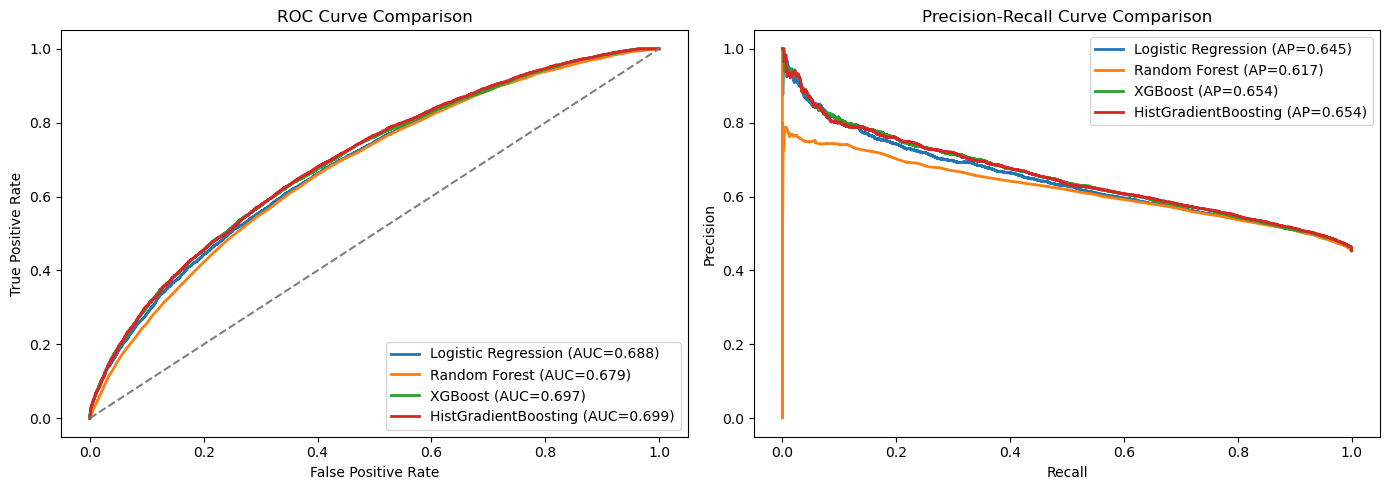

In [23]:
plt.figure(figsize=(14, 5))

# ---------------- ROC Curve ----------------
plt.subplot(1, 2, 1)
for name, metrics in test_results.items():
    y_test_proba = metrics['y_test_proba']  # Use stored probabilities
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")

# ---------------- Precision-Recall Curve ----------------
plt.subplot(1, 2, 2)
for name, metrics in test_results.items():
    y_test_proba = metrics['y_test_proba']  # Use stored probabilities
    precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
    avg_prec = average_precision_score(y_test, y_test_proba)
    plt.plot(recall, precision, lw=2, label=f"{name} (AP={avg_prec:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Optimization: Mathematical Decision Making for Resource Allocation

#### The Optimization Stage of Predict-then-Optimize

This section implements the **optimization stage** of our framework. We use the predicted readmission probabilities from our ML model to solve an optimization problem that determines which encounters should receive interventions.

We formulate this as a 0–1 knapsack problem, where the objective is to maximize the total benefit obtained from performing interventions while staying within a fixed budget.    

**Decision Variable**     
     
$Xi$ = 1 if encounter i receives an intervention; 0 otherwise

**Objective** 

This formulation captures the trade-off between the potential benefit of preventing readmissions and the cost of interventions, enabling optimal allocation of limited healthcare resources. 

$\max \sum_{i}  X_i (e P_i Cr_{a(i)} - Cint_{a(i)})$

where: 
* ${X_i}$: decision variable indicating whether encounter i receives an intervention
* ${e}$: effectiveness of the interventions in reducing readmission probability
* ${P_i}$: predicted readmission probability from the machine learning model
* $Cr_{a(i)}$​: estimated readmission cost assigned based on the patient’s age group
* $Cint_{a(i)}$: intervention cost assigned based on the patient’s age group

**Constraints**:   
There are two constraints in this problem:  
* Budget limit on total intervention costs: ensures that the total cost of all selected interventions does not exceed the available budget  
        
    $\sum_{i} X_i Cint_{a(i)} = B$

* Binary decision variable: ensures that each encounter is either selected for intervention or not

    $X_i ∈ \{0, 1\}, ∀i$

In [24]:
X_test_selected

,number_inpatient,number_diagnoses,number_emergency,number_outpatient,diabetesMed,time_in_hospital,diag_1,diag_2,diag_3,discharge_disposition_desc,admission_source_desc,insulin,admission_type_desc
13,0,8,0,0,1,10,428,411,427,Discharged/transferred to home with home healt...,Emergency Room,Steady,Emergency
22,0,8,0,0,0,2,410,401,582,Discharged to home,Transfer from a hospital,No,Urgent
30,0,9,0,0,1,6,584,496,250.42,Discharged to home,Emergency Room,Steady,Emergency
32,0,8,0,0,1,6,996,999,250.01,Discharged to home,Emergency Room,Steady,Emergency
39,0,9,0,0,1,1,996,403,250.41,Discharged to home,Clinic Referral,Steady,Urgent
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101749,0,9,1,0,1,3,715,401,250,Discharged/transferred to home with home healt...,Physician Referral,Steady,Elective
101750,0,9,0,0,1,3,574,574,250,Discharged to home,Physician Referral,Down,Elective
101753,0,9,0,0,1,13,250.8,730,731,Discharged to home,Emergency Room,Down,Emergency
101756,1,9,1,1,1,2,996,585,403,Discharged to home,Emergency Room,Steady,Emergency


In [25]:
test_results['HistGradientBoosting']['y_test_proba']

array([0.58355723, 0.24264843, 0.44548256, ..., 0.44709189, 0.66439751,
       0.48501612], shape=(20153,))

In [26]:
# Aggregate the testing data into a dataframe
df_results = X_test
df_results['y_prob'] = test_results['HistGradientBoosting']['y_test_proba']
df_results['y_test'] = y_test
df_results.head()
# len(df_results) # 20153


,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,admission_type_desc,discharge_disposition_desc,admission_source_desc,y_prob,y_test
13,42570,77586282,Caucasian,Male,[80-90),10,55,1,31,0,0,0,428,411,427,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.583557,0
22,182796,63000108,AfricanAmerican,Female,[70-80),2,47,0,12,0,0,0,410,401,582,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,Urgent,Discharged to home,Transfer from a hospital,0.242648,0
30,253380,56480238,AfricanAmerican,Female,[60-70),6,87,0,18,0,0,0,584,496,250.42,9,No,No,No,No,No,No,No,Up,No,No,No,Steady,No,No,No,Steady,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.445483,0
32,260166,80845353,Caucasian,Female,[70-80),6,27,0,16,0,0,0,996,999,250.01,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.354580,1
39,377268,104672268,Caucasian,Male,[50-60),1,44,1,15,0,0,0,996,403,250.41,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Urgent,Discharged to home,Clinic Referral,0.554785,1


In [27]:
df_results = df_results.reset_index(drop = True)
df_results.head()

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,admission_type_desc,discharge_disposition_desc,admission_source_desc,y_prob,y_test
0,42570,77586282,Caucasian,Male,[80-90),10,55,1,31,0,0,0,428,411,427,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.583557,0
1,182796,63000108,AfricanAmerican,Female,[70-80),2,47,0,12,0,0,0,410,401,582,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,Urgent,Discharged to home,Transfer from a hospital,0.242648,0
2,253380,56480238,AfricanAmerican,Female,[60-70),6,87,0,18,0,0,0,584,496,250.42,9,No,No,No,No,No,No,No,Up,No,No,No,Steady,No,No,No,Steady,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.445483,0
3,260166,80845353,Caucasian,Female,[70-80),6,27,0,16,0,0,0,996,999,250.01,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.354580,1
4,377268,104672268,Caucasian,Male,[50-60),1,44,1,15,0,0,0,996,403,250.41,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Urgent,Discharged to home,Clinic Referral,0.554785,1


#### Setting Parameters

We set the intervention cost and readmission cost based on different age groups.

In [28]:
intervention_cost = {
    '[0-10)': 180,    # Pediatric - simple monitoring, family education, low complexity
    '[10-20)': 220,   # Adolescent - basic diabetes education, peer support, moderate complexity
    '[20-30)': 280,   # Young adult - standard intervention package, lifestyle coaching
    '[30-40)': 350,   # Adult - comprehensive care management, medication adherence
    '[40-50)': 450,   # Middle-aged - enhanced monitoring, comorbidity management
    '[50-60)': 580,   # Pre-senior - complex care coordination, multiple specialists
    '[60-70)': 720,   # Senior - specialized geriatric care, fall prevention
    '[70-80)': 890,   # Elderly - intensive care management, polypharmacy management
    '[80-90)': 1100,  # Very elderly - high-touch intervention, caregiver support
    '[90-100)': 1350  # Most elderly - most complex, expensive care, end-of-life considerations
}  


In [29]:
readmission_costs = {
    '[0-10)': 5000,   # Pediatric - shorter stays, fewer complications
    '[10-20)': 5500,  # Adolescent - moderate complexity
    '[20-30)': 6000,  # Young adult - baseline readmission cost
    '[30-40)': 6500,  # Adult - slightly higher due to comorbidities
    '[40-50)': 7000,  # Middle-aged - increased complexity
    '[50-60)': 8000,  # Pre-senior - higher baseline (original $8000)
    '[60-70)': 9500,  # Senior - longer stays, more complications
    '[70-80)': 11000, # Elderly - much higher due to frailty
    '[80-90)': 13000, # Very elderly - highest complexity
    '[90-100)': 15000 # Most elderly - maximum readmission cost
}

In [30]:
# Map the costs to each encounter
df_results['intervention_cost'] = df_results['age'].map(intervention_cost)
df_results['readmission_cost'] = df_results['age'].map(readmission_costs)

In [31]:
df_results.head()

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,admission_type_desc,discharge_disposition_desc,admission_source_desc,y_prob,y_test,intervention_cost,readmission_cost
0,42570,77586282,Caucasian,Male,[80-90),10,55,1,31,0,0,0,428,411,427,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.583557,0,1100,13000
1,182796,63000108,AfricanAmerican,Female,[70-80),2,47,0,12,0,0,0,410,401,582,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,Urgent,Discharged to home,Transfer from a hospital,0.242648,0,890,11000
2,253380,56480238,AfricanAmerican,Female,[60-70),6,87,0,18,0,0,0,584,496,250.42,9,No,No,No,No,No,No,No,Up,No,No,No,Steady,No,No,No,Steady,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.445483,0,720,9500
3,260166,80845353,Caucasian,Female,[70-80),6,27,0,16,0,0,0,996,999,250.01,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.354580,1,890,11000
4,377268,104672268,Caucasian,Male,[50-60),1,44,1,15,0,0,0,996,403,250.41,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Urgent,Discharged to home,Clinic Referral,0.554785,1,580,8000


In [32]:
df_results['y_prob'].values[0:5]

array([0.58355723, 0.24264843, 0.44548256, 0.35457958, 0.55478468])

In [33]:
# Assume that the effectiveness (reduced readmission probability) is the same for every encounter.
intervention_effectiveness = 0.3 
n_patients = len(df_results)
orig_prob = df_results['y_prob'].values # Pi
readmission_cost = df_results['readmission_cost'].values # Cr
intervention_cost = df_results['intervention_cost'].values # Cint

#### Decision Variables

In [34]:
# Decision variable: 1 if intervene, 0 otherwise
m = gp.Model("maximize_benefit_under_budget")
intervene = m.addVars(n_patients, vtype=GRB.BINARY, name="intervene")

Set parameter Username
Set parameter LicenseID to value 2700807
Academic license - for non-commercial use only - expires 2026-08-28


#### Set the Objective

In [35]:
# Objective: maximize total benefit
m.setObjective(gp.quicksum(intervene[i] * (intervention_effectiveness * orig_prob[i] * readmission_cost[i] - intervention_cost[i])
        for i in range(n_patients)), GRB.MAXIMIZE)

#### Add Constraint: Budget Constraint


In [36]:
# Budget constraint
budget = 1000000
m.addConstr(gp.quicksum(intervene[i] * intervention_cost[i] for i in range(n_patients)) <= budget, "budget_limit")

<gurobi.Constr *Awaiting Model Update*>

#### Run Solver

In [37]:
# Optimize
m.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 20153 columns and 20153 nonzeros
Model fingerprint: 0xf6548de1
Variable types: 0 continuous, 20153 integer (20153 binary)
Coefficient statistics:
  Matrix range     [2e+02, 1e+03]
  Objective range  [1e-01, 2e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+06, 1e+06]
Found heuristic solution: objective 788235.94699
Presolve removed 0 rows and 2363 columns
Presolve time: 0.03s
Presolved: 1 rows, 17790 columns, 17790 nonzeros
Variable types: 0 continuous, 17790 integer (17364 binary)

Root relaxation: objective 2.242442e+06, 1 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 2242442.48    0    1 788235.947 224

#### Perform Analysis on the Result

In [38]:
df_results['selected_for_intervention'] = [intervene[i].x for i in range(n_patients)]
df_results

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,admission_type_desc,discharge_disposition_desc,admission_source_desc,y_prob,y_test,intervention_cost,readmission_cost,selected_for_intervention
0,42570,77586282,Caucasian,Male,[80-90),10,55,1,31,0,0,0,428,411,427,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.583557,0,1100,13000,-0.0
1,182796,63000108,AfricanAmerican,Female,[70-80),2,47,0,12,0,0,0,410,401,582,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,Urgent,Discharged to home,Transfer from a hospital,0.242648,0,890,11000,0.0
2,253380,56480238,AfricanAmerican,Female,[60-70),6,87,0,18,0,0,0,584,496,250.42,9,No,No,No,No,No,No,No,Up,No,No,No,Steady,No,No,No,Steady,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.445483,0,720,9500,0.0
3,260166,80845353,Caucasian,Female,[70-80),6,27,0,16,0,0,0,996,999,250.01,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.354580,1,890,11000,-0.0
4,377268,104672268,Caucasian,Male,[50-60),1,44,1,15,0,0,0,996,403,250.41,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Urgent,Discharged to home,Clinic Referral,0.554785,1,580,8000,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20148,443816024,106392411,Caucasian,Female,[70-80),3,27,1,29,0,1,0,715,401,250,9,Steady,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,1,1,Elective,Discharged/transferred to home with home healt...,Physician Referral,0.416782,0,890,11000,-0.0
20149,443824292,138784172,Caucasian,Female,[80-90),3,31,2,24,0,0,0,574,574,250,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,1,1,Elective,Discharged to home,Physician Referral,0.310450,1,1100,13000,-0.0
20150,443841992,184875899,Other,Male,[40-50),13,51,2,13,0,0,0,250.8,730,731,9,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.447092,0,450,7000,-0.0
20151,443842070,140199494,Other,Female,[60-70),2,46,6,17,1,1,1,996,585,403,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.664398,1,720,9500,-0.0


##### Business Impact
After obtaining the optimized intervention decisions, we compared the original expected readmission cost (without any intervention) with the expected cost after optimization. The difference between the two represents the cost savings achieved through targeted intervention allocation, demonstrating the effectiveness of the predict-then-optimize framework in improving resource utilization and reducing overall healthcare costs.

In [39]:
# Calculate the original expected readmission costs without interventions
df_results['costs_without_intervention'] = df_results['y_prob'] * df_results['readmission_cost']
df_results['costs_without_intervention'].sum()

np.float64(92064001.49616492)

In [40]:
# Calculate the expected costs with interventions
df_results['costs_with_intervention'] = (
    df_results['readmission_cost'] * df_results['y_prob'] * (1 - df_results['selected_for_intervention'] * intervention_effectiveness)
    + df_results['selected_for_intervention'] * df_results['intervention_cost']
)
df_results['costs_with_intervention'].sum()

np.float64(89821643.46925771)

In [41]:
# Calculate the expected costs savings with interventions
df_results['costs_savings'] = df_results['selected_for_intervention'] * (intervention_effectiveness * df_results['y_prob'] * df_results['readmission_cost'] - df_results['intervention_cost'])
df_results['costs_savings'].sum()

np.float64(2242358.0269071916)

We also examine the results by looking at the number of encounters selected for interventions.

In [42]:
# Examine the encounters selected for intervention
encounters_selected = len(df_results[df_results['selected_for_intervention'] == 1])
df_results[df_results['selected_for_intervention'] == 1]


,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,admission_type_desc,discharge_disposition_desc,admission_source_desc,y_prob,y_test,intervention_cost,readmission_cost,selected_for_intervention,costs_without_intervention,costs_with_intervention,costs_savings
48,2552952,86240259,Caucasian,Female,[70-80),11,44,0,19,0,1,6,276,8,496,8,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,1,1,Emergency,Discharged/transferred to SNF,Emergency Room,0.806632,1,890,11000,1.0,8872.951462,7101.066024,1771.885439
59,2652750,100605564,Caucasian,Male,[20-30),10,46,0,30,0,1,1,997,560,V42,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,Urgent,Discharged/transferred to home with home healt...,Clinic Referral,0.565558,1,280,6000,1.0,3393.350390,2655.345273,738.005117
91,3781500,28088019,AfricanAmerican,Female,[40-50),2,36,1,9,0,0,5,198,284,196,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.758696,0,450,7000,1.0,5310.874972,4167.612480,1143.262492
98,4086876,2892654,Caucasian,Male,[10-20),1,48,0,6,0,0,2,250.13,276,250.23,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Missing,Missing,Emergency Room,0.634677,1,220,5500,1.0,3490.724773,2663.507341,827.217432
109,4337124,9124884,Other,Male,[0-10),3,50,0,5,0,0,0,250.03,276,Missing,2,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Missing,Missing,Emergency Room,0.395622,0,180,5000,1.0,1978.110029,1564.677020,413.433009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20077,438499394,32218515,Caucasian,Male,[60-70),2,32,0,13,1,2,2,276,203,285,8,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.774027,1,720,9500,1.0,7353.257570,5867.280299,1485.977271
20089,439574054,84524355,Caucasian,Male,[30-40),9,62,0,7,0,1,4,577,276,309,4,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,Emergency,Discharged/transferred to home with home healt...,Physician Referral,0.686535,1,350,6500,1.0,4462.480445,3473.736312,988.744134
20132,442544042,40236012,AfricanAmerican,Male,[30-40),5,23,3,15,0,0,0,250.8,681,403,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,1,1,Elective,Discharged to home,Physician Referral,0.542431,0,350,6500,1.0,3525.800857,2818.060600,707.740257
20133,442552658,88227540,AfricanAmerican,Female,[40-50),10,45,1,11,5,5,10,250.6,70,997,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.919629,1,450,7000,1.0,6437.404350,4956.183045,1481.221305


After optimization, we allocate $999,960 to deliver 1,832 interventions, reducing the expected readmission spend from $92,064,001.50 to $89,821,643.47. This yields $2,242,358.03 in net savings and an ROI of 2.24. Every dollar invested returns $2.24 in net savings (about $3.24 in gross avoided readmission costs per dollar). These results support that our predict-then-optimize approach improves resource utilization and lowers overall costs under the given budget.

In [43]:
# Optimized results
print("--------- Result Summary ---------")
print(f"Spending in interventions:                           ${(df_results['intervention_cost'] * df_results['selected_for_intervention']).sum():,.2f}")
print(f"Number of encounters selected for interventions:        {encounters_selected:,.2f}")
print(f"Expected readmission cost (no intervention):      ${df_results['costs_without_intervention'].sum():,.2f}")
print(f"Expected total cost (with intervention):          ${df_results['costs_with_intervention'].sum():,.2f}")
print(f"Net benefit (savings net of cost):                 ${df_results['costs_savings'].sum():,.2f}")
print(f"ROI (Net Benefit / Cost):                                   {df_results['costs_savings'].sum()/budget:,.2f}")

--------- Result Summary ---------
Spending in interventions:                           $999,960.00
Number of encounters selected for interventions:        1,832.00
Expected readmission cost (no intervention):      $92,064,001.50
Expected total cost (with intervention):          $89,821,643.47
Net benefit (savings net of cost):                 $2,242,358.03
ROI (Net Benefit / Cost):                                   2.24


##### Validating the Policy: Not Just High-Risk Patients
To validate whether the model is truly optimizing the intervention list, we compared the selected encounters with those that have the highest predicted readmission probabilities. The results show about a 70% overlap, which indicates that the model is not simply targeting the encounters with the highest risk. Instead, it strategically allocates limited intervention resources toward encounters that offer the greatest potential cost savings.

In [44]:
top_idx = df_results.sort_values('y_prob', ascending=False).head(int(encounters_selected)).index

# Find overlap
selected_idx = df_results[df_results['selected_for_intervention'] == 1].index
overlap_ratio = len(set(top_idx) & set(selected_idx)) / encounters_selected if encounters_selected > 0 else 0

print(f"Overlap Ratio: {overlap_ratio*100:.2f}%")


Overlap Ratio: 70.14%


### What-if Analysis

#### Q1. What happens if we double the budget?     
To evaluate the sensitivity of our optimization model to resource availability, we conducted a what-if analysis by increasing the intervention budget to twice its original amount. This scenario examines how the model reallocates resources when more interventions can be funded.

In [45]:
# Decision variable: 1 if intervene, 0 otherwise
m = gp.Model("maximize_benefit_under_budget")
intervene = m.addVars(n_patients, vtype=GRB.BINARY, name="intervene")

# Objective: maximize total benefit
m.setObjective(gp.quicksum(intervene[i] * (intervention_effectiveness * orig_prob[i] * readmission_cost[i] - intervention_cost[i])
        for i in range(n_patients)), GRB.MAXIMIZE)

# Budget constraint
budget = 2000000
m.addConstr(gp.quicksum(intervene[i] * intervention_cost[i] for i in range(n_patients)) <= budget, "budget_limit")

# Optimize
m.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 20153 columns and 20153 nonzeros
Model fingerprint: 0x54321a24
Variable types: 0 continuous, 20153 integer (20153 binary)
Coefficient statistics:
  Matrix range     [2e+02, 1e+03]
  Objective range  [1e-01, 2e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+06, 2e+06]
Found heuristic solution: objective 1624995.3817
Presolve removed 0 rows and 2363 columns
Presolve time: 0.03s
Presolved: 1 rows, 17790 columns, 17790 nonzeros
Variable types: 0 continuous, 17790 integer (17364 binary)

Root relaxation: objective 3.883042e+06, 1 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 3883042.37    0    1 1624995.38 388

In [46]:
df_results['selected_for_intervention(double budget)'] = [intervene[i].x for i in range(n_patients)]
df_results

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,admission_type_desc,discharge_disposition_desc,admission_source_desc,y_prob,y_test,intervention_cost,readmission_cost,selected_for_intervention,costs_without_intervention,costs_with_intervention,costs_savings,selected_for_intervention(double budget)
0,42570,77586282,Caucasian,Male,[80-90),10,55,1,31,0,0,0,428,411,427,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.583557,0,1100,13000,-0.0,7586.243978,7586.243978,-0.0,0.0
1,182796,63000108,AfricanAmerican,Female,[70-80),2,47,0,12,0,0,0,410,401,582,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,Urgent,Discharged to home,Transfer from a hospital,0.242648,0,890,11000,0.0,2669.132690,2669.132690,-0.0,0.0
2,253380,56480238,AfricanAmerican,Female,[60-70),6,87,0,18,0,0,0,584,496,250.42,9,No,No,No,No,No,No,No,Up,No,No,No,Steady,No,No,No,Steady,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.445483,0,720,9500,0.0,4232.084327,4232.084327,0.0,0.0
3,260166,80845353,Caucasian,Female,[70-80),6,27,0,16,0,0,0,996,999,250.01,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.354580,1,890,11000,-0.0,3900.375359,3900.375359,-0.0,-0.0
4,377268,104672268,Caucasian,Male,[50-60),1,44,1,15,0,0,0,996,403,250.41,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Urgent,Discharged to home,Clinic Referral,0.554785,1,580,8000,-0.0,4438.277471,4438.277471,-0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20148,443816024,106392411,Caucasian,Female,[70-80),3,27,1,29,0,1,0,715,401,250,9,Steady,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,1,1,Elective,Discharged/transferred to home with home healt...,Physician Referral,0.416782,0,890,11000,-0.0,4584.605913,4584.605913,-0.0,-0.0
20149,443824292,138784172,Caucasian,Female,[80-90),3,31,2,24,0,0,0,574,574,250,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,1,1,Elective,Discharged to home,Physician Referral,0.310450,1,1100,13000,-0.0,4035.856259,4035.856259,-0.0,-0.0
20150,443841992,184875899,Other,Male,[40-50),13,51,2,13,0,0,0,250.8,730,731,9,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.447092,0,450,7000,-0.0,3129.643197,3129.643197,-0.0,-0.0
20151,443842070,140199494,Other,Female,[60-70),2,46,6,17,1,1,1,996,585,403,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.664398,1,720,9500,-0.0,6311.776321,6311.776321,-0.0,1.0


In [47]:
# Calculate the expected costs with interventions
df_results['costs_with_intervention(double budget)'] = (
    df_results['readmission_cost'] * df_results['y_prob'] * (1 - df_results['selected_for_intervention(double budget)'] * intervention_effectiveness)
    + df_results['selected_for_intervention(double budget)'] * df_results['intervention_cost']
)
df_results['costs_with_intervention(double budget)'].sum()

np.float64(88181250.55732307)

In [48]:
# Calculate the expected costs savings with interventions
df_results['costs_savings(double budget)'] = df_results['selected_for_intervention(double budget)'] * (intervention_effectiveness * df_results['y_prob'] * df_results['readmission_cost'] - df_results['intervention_cost'])
df_results['costs_savings(double budget)'].sum()

np.float64(3882750.938841852)

In [49]:
# Examine the encounters selected for intervention
encounters_selected_double = len(df_results[df_results['selected_for_intervention(double budget)'] == 1])
df_results[df_results['selected_for_intervention(double budget)'] == 1]

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,admission_type_desc,discharge_disposition_desc,admission_source_desc,y_prob,y_test,intervention_cost,readmission_cost,selected_for_intervention,costs_without_intervention,costs_with_intervention,costs_savings,selected_for_intervention(double budget),costs_with_intervention(double budget),costs_savings(double budget)
7,486156,86240259,Caucasian,Female,[70-80),9,25,3,16,0,0,2,428,427,250.01,7,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,Down,No,No,No,No,No,1,1,Elective,Discharged/transferred to another type of inpa...,Transfer from a hospital,0.704100,1,890,11000,-0.0,7745.100584,7745.100584,-0.000000,1.0,6311.570409,1433.530175
37,2305260,2780676,AfricanAmerican,Male,[30-40),3,44,1,4,0,0,0,682,250.03,41,3,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,1,1,Missing,Missing,Emergency Room,0.429864,0,350,6500,-0.0,2794.115929,2794.115929,-0.000000,1.0,2305.881150,488.234779
41,2473188,981198,Caucasian,Female,[60-70),5,47,3,24,0,0,0,250.4,403,276,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Missing,Missing,Physician Referral,0.579636,1,720,9500,-0.0,5506.544607,5506.544607,-0.000000,1.0,4574.581225,931.963382
48,2552952,86240259,Caucasian,Female,[70-80),11,44,0,19,0,1,6,276,8,496,8,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,1,1,Emergency,Discharged/transferred to SNF,Emergency Room,0.806632,1,890,11000,1.0,8872.951462,7101.066024,1771.885439,1.0,7101.066024,1771.885439
54,2595384,3151539,AfricanAmerican,Male,[20-30),5,70,0,8,0,0,0,70,276,250.01,3,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Missing,Missing,Emergency Room,0.431349,0,280,6000,-0.0,2588.096488,2588.096488,-0.000000,1.0,2091.667542,496.428947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20133,442552658,88227540,AfricanAmerican,Female,[40-50),10,45,1,11,5,5,10,250.6,70,997,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.919629,1,450,7000,1.0,6437.404350,4956.183045,1481.221305,1.0,4956.183045,1481.221305
20135,443138246,55146366,AfricanAmerican,Female,[50-60),4,38,2,22,0,0,2,428,682,786,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,1,1,Missing,Discharged/transferred to home with home healt...,Missing,0.661901,0,580,8000,-0.0,5295.210625,5295.210625,-0.000000,1.0,4286.647437,1008.563187
20136,443191964,125535857,Caucasian,Male,[10-20),3,44,0,10,0,0,0,250.13,287,E849,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.363627,0,220,5500,-0.0,1999.948296,1999.948296,-0.000000,1.0,1619.963807,379.984489
20140,443198486,29401542,AfricanAmerican,Male,[60-70),1,28,1,24,0,0,4,786,414,585,9,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.707510,1,720,9500,1.0,6721.344317,5424.941022,1296.403295,1.0,5424.941022,1296.403295


When the intervention budget was doubled from $1,000,000 to $2,000,000, the number of encounters selected for interventions increased from 1,832 to 3,228, enabling more patients to receive preventive care. Consequently, the expected total cost with interventions decreased from $89.82 million to $88.18 million, leading to higher overall savings.
However, while the net benefit increased from $2.24 million to $3.88 million, the ROI (Return on Investment) declined from 2.24 to 1.94. This indicates diminishing marginal returns, as more patients receive interventions, the additional savings per dollar spent decrease.

In [50]:
# Optimized results
print("--------- Result Summary (Double Budget) ---------")
print(f"Spending in interventions:                           ${(df_results['intervention_cost'] * df_results['selected_for_intervention(double budget)']).sum():,.2f}")
print(f"Number of encounters selected for interventions:          {encounters_selected_double:,.2f}")
print(f"Expected readmission cost (no intervention):        ${df_results['costs_without_intervention'].sum():,.2f}")
print(f"Expected total cost (with intervention):            ${df_results['costs_with_intervention(double budget)'].sum():,.2f}")
print(f"Net benefit (savings net of cost):                   ${df_results['costs_savings(double budget)'].sum():,.2f}")
print(f"ROI (Net Benefit / Cost):                                     {df_results['costs_savings(double budget)'].sum()/budget:,.2f}")

--------- Result Summary (Double Budget) ---------
Spending in interventions:                           $1,999,990.00
Number of encounters selected for interventions:          3,228.00
Expected readmission cost (no intervention):        $92,064,001.50
Expected total cost (with intervention):            $88,181,250.56
Net benefit (savings net of cost):                   $3,882,750.94
ROI (Net Benefit / Cost):                                     1.94


In [51]:
top_idx = df_results.sort_values('y_prob', ascending=False).head(int(encounters_selected)).index

# Find overlap
selected_idx = df_results[df_results['selected_for_intervention(double budget)'] == 1].index
overlap_ratio = len(set(top_idx) & set(selected_idx)) / encounters_selected if encounters_selected > 0 else 0

print(f"Overlap Ratio: {overlap_ratio*100:.2f}%")

Overlap Ratio: 96.40%


#### Q2. What if intervention effectiveness decreases by 5%?
In this case, we try to reduce the intervention effectiveness by 5% to examine how the optimization outcomes respond to changes in clinical impact. This scenario helps simulates real-world uncertainty, such as reduced patient adherence or variability in care quality.

In [52]:
intervention_effectiveness = 0.25
# Decision variable: 1 if intervene, 0 otherwise
m = gp.Model("maximize_benefit_under_budget")
intervene = m.addVars(n_patients, vtype=GRB.BINARY, name="intervene")

# Objective: maximize total benefit
m.setObjective(gp.quicksum(intervene[i] * (intervention_effectiveness * orig_prob[i] * readmission_cost[i] - intervention_cost[i])
        for i in range(n_patients)), GRB.MAXIMIZE)

# Budget constraint
budget = 1000000
m.addConstr(gp.quicksum(intervene[i] * intervention_cost[i] for i in range(n_patients)) <= budget, "budget_limit")

# Optimize
m.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 20153 columns and 20153 nonzeros
Model fingerprint: 0xa2ea0f88
Variable types: 0 continuous, 20153 integer (20153 binary)
Coefficient statistics:
  Matrix range     [2e+02, 1e+03]
  Objective range  [2e-02, 2e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+06, 1e+06]
Found heuristic solution: objective 567029.51083
Presolve removed 0 rows and 3869 columns
Presolve time: 0.02s
Presolved: 1 rows, 16284 columns, 16284 nonzeros
Variable types: 0 continuous, 16284 integer (15918 binary)

Root relaxation: objective 1.702035e+06, 1 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 1702035.40    0    1 567029.511 170

In [53]:
df_results['selected_for_intervention(reduced e)'] = [intervene[i].x for i in range(n_patients)]
df_results

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,admission_type_desc,discharge_disposition_desc,admission_source_desc,y_prob,y_test,intervention_cost,readmission_cost,selected_for_intervention,costs_without_intervention,costs_with_intervention,costs_savings,selected_for_intervention(double budget),costs_with_intervention(double budget),costs_savings(double budget),selected_for_intervention(reduced e)
0,42570,77586282,Caucasian,Male,[80-90),10,55,1,31,0,0,0,428,411,427,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.583557,0,1100,13000,-0.0,7586.243978,7586.243978,-0.0,0.0,7586.243978,0.000000,-0.0
1,182796,63000108,AfricanAmerican,Female,[70-80),2,47,0,12,0,0,0,410,401,582,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,Urgent,Discharged to home,Transfer from a hospital,0.242648,0,890,11000,0.0,2669.132690,2669.132690,-0.0,0.0,2669.132690,-0.000000,0.0
2,253380,56480238,AfricanAmerican,Female,[60-70),6,87,0,18,0,0,0,584,496,250.42,9,No,No,No,No,No,No,No,Up,No,No,No,Steady,No,No,No,Steady,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.445483,0,720,9500,0.0,4232.084327,4232.084327,0.0,0.0,4232.084327,0.000000,-0.0
3,260166,80845353,Caucasian,Female,[70-80),6,27,0,16,0,0,0,996,999,250.01,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.354580,1,890,11000,-0.0,3900.375359,3900.375359,-0.0,-0.0,3900.375359,-0.000000,-0.0
4,377268,104672268,Caucasian,Male,[50-60),1,44,1,15,0,0,0,996,403,250.41,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Urgent,Discharged to home,Clinic Referral,0.554785,1,580,8000,-0.0,4438.277471,4438.277471,-0.0,0.0,4438.277471,0.000000,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20148,443816024,106392411,Caucasian,Female,[70-80),3,27,1,29,0,1,0,715,401,250,9,Steady,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,1,1,Elective,Discharged/transferred to home with home healt...,Physician Referral,0.416782,0,890,11000,-0.0,4584.605913,4584.605913,-0.0,-0.0,4584.605913,-0.000000,-0.0
20149,443824292,138784172,Caucasian,Female,[80-90),3,31,2,24,0,0,0,574,574,250,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,1,1,Elective,Discharged to home,Physician Referral,0.310450,1,1100,13000,-0.0,4035.856259,4035.856259,-0.0,-0.0,4035.856259,-0.000000,0.0
20150,443841992,184875899,Other,Male,[40-50),13,51,2,13,0,0,0,250.8,730,731,9,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,1,1,Emergency,Discharged to home,Emergency Room,0.447092,0,450,7000,-0.0,3129.643197,3129.643197,-0.0,-0.0,3129.643197,-0.000000,-0.0
20151,443842070,140199494,Other,Female,[60-70),2,46,6,17,1,1,1,996,585,403,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.664398,1,720,9500,-0.0,6311.776321,6311.776321,-0.0,1.0,5138.243425,1173.532896,-0.0


In [54]:
# Calculate the expected costs with interventions
df_results['costs_with_intervention(reduced e)'] = (
    df_results['readmission_cost'] * df_results['y_prob'] * (1 - df_results['selected_for_intervention(reduced e)'] * intervention_effectiveness)
    + df_results['selected_for_intervention(reduced e)'] * df_results['intervention_cost']
)
df_results['costs_with_intervention(reduced e)'].sum()

np.float64(90362029.80707559)

In [55]:
# Calculate the expected costs savings with interventions
df_results['costs_savings(reduced e)'] = df_results['selected_for_intervention(reduced e)'] * (intervention_effectiveness * df_results['y_prob'] * df_results['readmission_cost'] - df_results['intervention_cost'])
df_results['costs_savings(reduced e)'].sum()

np.float64(1701971.6890893262)

In [56]:
# Examine the encounters selected for intervention
encounters_selected_double = len(df_results[df_results['selected_for_intervention(reduced e)'] == 1])
df_results[df_results['selected_for_intervention(reduced e)'] == 1]

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,admission_type_desc,discharge_disposition_desc,admission_source_desc,y_prob,y_test,intervention_cost,readmission_cost,selected_for_intervention,costs_without_intervention,costs_with_intervention,costs_savings,selected_for_intervention(double budget),costs_with_intervention(double budget),costs_savings(double budget),selected_for_intervention(reduced e),costs_with_intervention(reduced e),costs_savings(reduced e)
48,2552952,86240259,Caucasian,Female,[70-80),11,44,0,19,0,1,6,276,8,496,8,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,1,1,Emergency,Discharged/transferred to SNF,Emergency Room,0.806632,1,890,11000,1.0,8872.951462,7101.066024,1771.885439,1.0,7101.066024,1771.885439,1.0,7544.713597,1328.237866
59,2652750,100605564,Caucasian,Male,[20-30),10,46,0,30,0,1,1,997,560,V42,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,Urgent,Discharged/transferred to home with home healt...,Clinic Referral,0.565558,1,280,6000,1.0,3393.350390,2655.345273,738.005117,1.0,2655.345273,738.005117,1.0,2825.012793,568.337598
91,3781500,28088019,AfricanAmerican,Female,[40-50),2,36,1,9,0,0,5,198,284,196,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged to home,Emergency Room,0.758696,0,450,7000,1.0,5310.874972,4167.612480,1143.262492,1.0,4167.612480,1143.262492,1.0,4433.156229,877.718743
98,4086876,2892654,Caucasian,Male,[10-20),1,48,0,6,0,0,2,250.13,276,250.23,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Missing,Missing,Emergency Room,0.634677,1,220,5500,1.0,3490.724773,2663.507341,827.217432,1.0,2663.507341,827.217432,1.0,2838.043579,652.681193
109,4337124,9124884,Other,Male,[0-10),3,50,0,5,0,0,0,250.03,276,Missing,2,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Missing,Missing,Emergency Room,0.395622,0,180,5000,1.0,1978.110029,1564.677020,413.433009,1.0,1564.677020,413.433009,1.0,1663.582521,314.527507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20077,438499394,32218515,Caucasian,Male,[60-70),2,32,0,13,1,2,2,276,203,285,8,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.774027,1,720,9500,1.0,7353.257570,5867.280299,1485.977271,1.0,5867.280299,1485.977271,1.0,6234.943178,1118.314393
20089,439574054,84524355,Caucasian,Male,[30-40),9,62,0,7,0,1,4,577,276,309,4,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,Emergency,Discharged/transferred to home with home healt...,Physician Referral,0.686535,1,350,6500,1.0,4462.480445,3473.736312,988.744134,1.0,3473.736312,988.744134,1.0,3696.860334,765.620111
20132,442544042,40236012,AfricanAmerican,Male,[30-40),5,23,3,15,0,0,0,250.8,681,403,8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,1,1,Elective,Discharged to home,Physician Referral,0.542431,0,350,6500,1.0,3525.800857,2818.060600,707.740257,1.0,2818.060600,707.740257,1.0,2994.350643,531.450214
20133,442552658,88227540,AfricanAmerican,Female,[40-50),10,45,1,11,5,5,10,250.6,70,997,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,Emergency,Discharged/transferred to home with home healt...,Emergency Room,0.919629,1,450,7000,1.0,6437.404350,4956.183045,1481.221305,1.0,4956.183045,1481.22

When the intervention effectiveness was reduced by 5%, the number of encounters selected for intervention remained the same (1,832), since the budget and cost structure did not change. However, the expected total cost with interventions increased from $89.82 million in the baseline scenario to $90.36 million, resulting in a smaller net benefit of $1.70 million compared to $2.24 million originally.    

Consequently, the ROI declined from 2.24 to 1.70, indicating that the return per dollar spent dropped notably due to the diminished impact of each intervention.    

This demonstrates that the overall optimization framework remains effective under reduced effectiveness but becomes less cost-efficient, as each intervention yields smaller reductions in readmission costs. In practical terms, it highlights the importance of maintaining high intervention quality and patient adherence, as small decreases in effectiveness can significantly impact the financial and clinical outcomes of healthcare resource allocation.

In [57]:
# Optimized results
print("--------- Result Summary (Reduced e) ---------")
print(f"Spending in interventions:                             ${(df_results['intervention_cost'] * df_results['selected_for_intervention(reduced e)']).sum():,.2f}")
print(f"Number of encounters selected for interventions:          {encounters_selected_double:,.2f}")
print(f"Expected readmission cost (no intervention):        ${df_results['costs_without_intervention'].sum():,.2f}")
print(f"Expected total cost (with intervention):            ${df_results['costs_with_intervention(reduced e)'].sum():,.2f}")
print(f"Net benefit (savings net of cost):                   ${df_results['costs_savings(reduced e)'].sum():,.2f}")
print(f"ROI (Net Benefit / Cost):                                     {df_results['costs_savings(reduced e)'].sum()/budget:,.2f}")

--------- Result Summary (Reduced e) ---------
Spending in interventions:                             $999,960.00
Number of encounters selected for interventions:          1,832.00
Expected readmission cost (no intervention):        $92,064,001.50
Expected total cost (with intervention):            $90,362,029.81
Net benefit (savings net of cost):                   $1,701,971.69
ROI (Net Benefit / Cost):                                     1.70


In [58]:
# Find the indices of encounters selected for intervention
original_selected = df_results.index[df_results['selected_for_intervention'] == 1]
reduced_e_selected = df_results.index[df_results['selected_for_intervention(reduced e)'] == 1]

# Calculate the number of overlapping indices
overlap_count = len(set(original_selected) & set(reduced_e_selected))

# Calculate overlap rates (based on original)
overlap_rate_original = overlap_count / len(original_selected)

print(f"Number of overlapping encounters: {overlap_count}")
print(f"Overlap rate (based on original): {overlap_rate_original:.2%}")


Number of overlapping encounters: 1832
Overlap rate (based on original): 100.00%
